In [ ]:
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_install("openai")
_install("graphviz")

import re, json, textwrap, os, getpass
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional
from datetime import datetime

try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
    if not OPENAI_API_KEY:
        raise ValueError
    print("✅  Loaded OPENAI_API_KEY from Colab secrets.")
except Exception:
    OPENAI_API_KEY = getpass.getpass("🔑 Enter your OpenAI API key: ")
    print("✅  API key received.")

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

from openai import OpenAI
client = OpenAI(api_key=OPENAI_API_KEY)

print("\n" + "=" * 72)
print("  IWE Advanced Tutorial — Knowledge Graph + AI Agents")
print("=" * 72)

@dataclass
class Section:
    level: int
    title: str
    content: str
    children: list = field(default_factory=list)

@dataclass
class Document:
    key: str
    title: str
    raw_content: str
    sections: list = field(default_factory=list)
    outgoing_links: list = field(default_factory=list)
    tags: list = field(default_factory=list)
    created: str = ""
    modified: str = ""


class KnowledgeGraph:

    def __init__(self):
        self.documents: dict[str, Document] = {}
        self.backlinks: dict[str, set] = defaultdict(set)

    _WIKI_LINK = re.compile(r"\[\[([^\]|]+)(?:\|([^\]]+))?\]\]")
    _MD_LINK   = re.compile(r"\[([^\]]+)\]\(([^)]+)\)")
    _HEADER    = re.compile(r"^(#{1,6})\s+(.+)", re.MULTILINE)
    _TAG       = re.compile(r"#([a-zA-Z][\w/-]*)")

    def _extract_links(self, text: str) -> list[str]:
        links = []
        for match in self._WIKI_LINK.finditer(text):
            links.append(match.group(1).strip())
        for match in self._MD_LINK.finditer(text):
            target = match.group(2).strip()
            if not target.startswith("http"):
                target = target.replace(".md", "")
                links.append(target)
        return links

    def _parse_sections(self, text: str) -> list[Section]:
        sections = []
        parts = self._HEADER.split(text)
        i = 1
        while i < len(parts) - 1:
            level = len(parts[i])
            title = parts[i + 1].strip()
            body = parts[i + 2] if i + 2 < len(parts) else ""
            sections.append(Section(level=level, title=title, content=body.strip()))
            i += 3
        return sections

    def _extract_tags(self, text: str) -> list[str]:
        tags = set()
        for line in text.split("\n"):
            if line.strip().startswith("#") and " " in line.strip():
                stripped = re.sub(r"^#{1,6}\s+.*", "", line)
                for m in self._TAG.finditer(stripped):
                    tags.add(m.group(1))
            else:
                for m in self._TAG.finditer(line):
                    tags.add(m.group(1))
        return sorted(tags)

    def add_document(self, key: str, content: str) -> Document:
        sections = self._parse_sections(content)
        title = sections[0].title if sections else key
        links = self._extract_links(content)
        tags = self._extract_tags(content)
        now = datetime.now().strftime("%Y-%m-%d %H:%M")

        doc = Document(
            key=key, title=title, raw_content=content,
            sections=sections, outgoing_links=links, tags=tags,
            created=now, modified=now,
        )
        self.documents[key] = doc

        for target in links:
            self.backlinks[target].add(key)

        return doc

    def get(self, key: str) -> Optional[Document]:
        return self.documents.get(key)

    def find(self, query: str, roots_only: bool = False, limit: int = 10) -> list[str]:
        q = query.lower()
        scored = []
        for key, doc in self.documents.items():
            score = 0
            if q in doc.title.lower():
                score += 10
            if q in doc.raw_content.lower():
                score += doc.raw_content.lower().count(q)
            if q in key.lower():
                score += 5
            for tag in doc.tags:
                if q in tag.lower():
                    score += 3
            if score > 0:
                scored.append((key, score))
        scored.sort(key=lambda x: -x[1])

        results = [k for k, _ in scored[:limit]]
        if roots_only:
            results = [k for k in results if not self.backlinks.get(k)]
        return results

    def retrieve(self, key: str, depth: int = 1, context: int = 1,
                 exclude: set = None) -> str:
        exclude = exclude or set()
        parts = []

        if context > 0:
            parents_of = list(self.backlinks.get(key, set()) - exclude)
            for p in parents_of[:context]:
                pdoc = self.get(p)
                if pdoc:
                    parts.append(f"[CONTEXT: {pdoc.title}]\n{pdoc.raw_content[:300]}...\n")
                    exclude.add(p)

        doc = self.get(key)
        if not doc:
            return f"⚠ Document '{key}' not found."
        parts.append(doc.raw_content)
        exclude.add(key)

        if depth > 0:
            for link in doc.outgoing_links:
                if link not in exclude:
                    child = self.get(link)
                    if child:
                        parts.append(f"\n---\n[LINKED: {child.title}]\n")
                        parts.append(
                            self.retrieve(link, depth=depth - 1,
                                          context=0, exclude=exclude)
                        )
        return "\n".join(parts)

    def tree(self, key: str, indent: int = 0, _visited: set = None) -> str:
        _visited = _visited if _visited is not None else set()
        doc = self.get(key)
        if not doc:
            return ""
        prefix = "  " * indent + ("└─ " if indent else "")
        if key in _visited:
            return f"{prefix}{doc.title} ({key}) ↩ (circular ref)"
        _visited.add(key)
        lines = [f"{prefix}{doc.title} ({key})"]
        for link in doc.outgoing_links:
            if self.get(link):
                lines.append(self.tree(link, indent + 1, _visited))
        return "\n".join(lines)

    def squash(self, key: str, visited: set = None) -> str:
        visited = visited or set()
        doc = self.get(key)
        if not doc or key in visited:
            return ""
        visited.add(key)
        parts = [doc.raw_content]
        for link in doc.outgoing_links:
            child_content = self.squash(link, visited)
            if child_content:
                parts.append(f"\n{'─' * 40}\n")
                parts.append(child_content)
        return "\n".join(parts)

    def stats(self) -> dict:
        total_words = sum(len(d.raw_content.split()) for d in self.documents.values())
        total_links = sum(len(d.outgoing_links) for d in self.documents.values())
        orphans = [k for k in self.documents if not self.backlinks.get(k)
                   and not self.documents[k].outgoing_links]
        all_tags = set()
        for d in self.documents.values():
            all_tags.update(d.tags)
        return {
            "total_documents": len(self.documents),
            "total_words": total_words,
            "total_links": total_links,
            "unique_tags": len(all_tags),
            "tags": sorted(all_tags),
            "orphan_notes": orphans,
            "avg_words_per_doc": total_words // max(len(self.documents), 1),
        }

    def export_dot(self, highlight_key: str = None) -> str:
        lines = ['digraph KnowledgeGraph {',
                 '  rankdir=LR;',
                 '  node [shape=box, style="rounded,filled", fillcolor="#f0f4ff", '
                 'fontname="Helvetica", fontsize=10];',
                 '  edge [color="#666666", arrowsize=0.7];']
        for key, doc in self.documents.items():
            label = doc.title[:30]
            color = '#ffe4b5' if highlight_key == key else '#f0f4ff'
            lines.append(f'  "{key}" [label="{label}", fillcolor="{color}"];')
        for key, doc in self.documents.items():
            for link in doc.outgoing_links:
                if link in self.documents:
                    lines.append(f'  "{key}" -> "{link}";')
        lines.append("}")
        return "\n".join(lines)


print("\n✅  Section 1 complete — KnowledgeGraph class defined.\n")

In [ ]:
kg = KnowledgeGraph()

kg.add_document("project-index", """# Web App Project

This is the **Map of Content** for our web application project.

## Architecture

- [Authentication System](authentication)
- [Database Design](database-design)
- [API Design](api-design)

## Development

- [Frontend Stack](frontend-stack)
- [Deployment Pipeline](deployment)

## Research

- [[caching-strategies]]
- [[performance-notes]]
""")

kg.add_document("authentication", """# Authentication System

Our app uses **JWT-based authentication** with refresh tokens.

## Flow

1. User submits credentials to `/api/auth/login`
2. Server validates against [Database Design](database-design) user table
3. Returns short-lived access token (15 min) + refresh token (7 days)
4. Client stores refresh token in HTTP-only cookie

## Security Considerations

- Passwords hashed with bcrypt (cost factor 12)
- Rate limiting on login endpoint: 5 attempts / minute
- Refresh token rotation on each use
- See [[caching-strategies]] for session caching

#security #jwt #auth
""")

kg.add_document("database-design", """# Database Design

We use **PostgreSQL 16** with the following core tables.

## Users Table

```sql
CREATE TABLE users (
    id          UUID PRIMARY KEY DEFAULT gen_random_uuid(),
    email       VARCHAR(255) UNIQUE NOT NULL,
    password    VARCHAR(255) NOT NULL,
    created_at  TIMESTAMPTZ DEFAULT NOW()
);
```

## Sessions Table

```sql
CREATE TABLE sessions (
    id          UUID PRIMARY KEY,
    user_id     UUID REFERENCES users(id),
    token_hash  VARCHAR(255) NOT NULL,
    expires_at  TIMESTAMPTZ NOT NULL
);
```

## Indexing Strategy

- B-tree on `users.email` for login lookups
- B-tree on `sessions.token_hash` for token validation
- See [[performance-notes]] for query optimization

#database #postgresql #schema
""")

kg.add_document("api-design", """# API Design

RESTful API following OpenAPI 3.0 specification.

## Endpoints

| Method | Path | Description |
|--------|------|-------------|
| POST | /api/auth/login | Authenticate user |
| POST | /api/auth/refresh | Refresh access token |
| GET | /api/users/me | Get current user profile |
| PUT | /api/users/me | Update profile |

## Error Handling

All errors return JSON with `{ "error": "code", "message": "..." }`.

Authentication endpoints documented in [Authentication System](authentication).
Data models align with [Database Design](database-design).

#api #rest #openapi
""")

kg.add_document("frontend-stack", """# Frontend Stack

## Technology Choices

- **Framework**: React 19 with Server Components
- **Styling**: Tailwind CSS v4
- **State Management**: Zustand for client state
- **Data Fetching**: TanStack Query v5

## Auth Integration

The frontend consumes the [API Design](api-design) endpoints.
Access tokens are stored in memory (not localStorage) for security.
Refresh handled transparently via Axios interceptors.

#frontend #react #tailwind
""")

kg.add_document("deployment", """# Deployment Pipeline

## Infrastructure

- **Container Runtime**: Docker with multi-stage builds
- **Orchestration**: Kubernetes on GKE
- **CI/CD**: GitHub Actions → Google Artifact Registry → GKE

## Pipeline Stages

1. Lint & type-check
2. Unit tests (Jest + pytest)
3. Build Docker images
4. Push to Artifact Registry
5. Deploy to staging (auto)
6. Deploy to production (manual approval)

## Monitoring

- Prometheus + Grafana for metrics
- Structured logging with correlation IDs
- See [[performance-notes]] for SLOs

#devops #kubernetes #cicd
""")

kg.add_document("caching-strategies", """# Caching Strategies

## Application-Level Caching

- **Redis** for session storage and rate limiting
- Cache-aside pattern for frequently accessed user profiles
- TTL: 5 minutes for profiles, 15 minutes for config

## HTTP Caching

- `Cache-Control: private, max-age=0` for authenticated endpoints
- `Cache-Control: public, max-age=3600` for static assets
- ETag support for conditional requests

## Cache Invalidation

- Event-driven invalidation via pub/sub
- Versioned cache keys: `user:{id}:v{version}`

Related: [Authentication System](authentication) uses Redis for refresh tokens.

#caching #redis #performance
""")

kg.add_document("performance-notes", """# Performance Notes

## Database Query Optimization

- Use `EXPLAIN ANALYZE` before deploying new queries
- Connection pooling with PgBouncer (max 50 connections)
- Avoid N+1 queries — use JOINs or DataLoader pattern

## SLO Targets

| Metric | Target | Current |
|--------|--------|---------|
| p99 latency | < 200ms | 180ms |
| Availability | 99.9% | 99.95% |
| Error rate | < 0.1% | 0.05% |

## Load Testing

- k6 scripts in `/tests/load/`
- Baseline: 1000 RPS sustained
- Spike: 5000 RPS for 60 seconds

Related to [Database Design](database-design) indexing and [[caching-strategies]].

#performance #slo #monitoring
""")

print("✅  Section 2 complete — 8 documents loaded into knowledge graph.\n")

print("─" * 72)
print("  3A · iwe find — Search the Knowledge Graph")
print("─" * 72)

results = kg.find("authentication")
print(f"\n🔍 find('authentication'): {results}")

results = kg.find("performance")
print(f"🔍 find('performance'):    {results}")

results = kg.find("cache", roots_only=True)
print(f"🔍 find('cache', roots_only=True): {results}")

print("\n" + "─" * 72)
print("  3B · iwe tree — Document Hierarchy")
print("─" * 72)
print()
print(kg.tree("project-index"))

print("\n" + "─" * 72)
print("  3C · iwe stats — Knowledge Base Statistics")
print("─" * 72)

stats = kg.stats()
for k, v in stats.items():
    print(f"  {k:>25s}: {v}")

print("\n" + "─" * 72)
print("  3D · iwe retrieve — Context-Aware Retrieval")
print("─" * 72)

print("\n📄 Retrieving 'authentication' with depth=1, context=1:\n")
retrieved = kg.retrieve("authentication", depth=1, context=1)
print(retrieved[:800] + "\n... (truncated)")

print("\n" + "─" * 72)
print("  3E · iwe squash — Combine Documents")
print("─" * 72)

squashed = kg.squash("project-index")
print(f"\n📋 Squashed 'project-index': {len(squashed)} characters, "
      f"{len(squashed.split())} words")

print("\n" + "─" * 72)
print("  3F · iwe export dot — Graph Visualization")
print("─" * 72)

dot_output = kg.export_dot(highlight_key="project-index")
print(f"\n🎨 DOT output ({len(dot_output)} chars):\n")
print(dot_output[:500] + "\n...")

try:
    import graphviz
    src = graphviz.Source(dot_output)
    src.render("knowledge_graph", format="png", cleanup=True)
    print("\n✅  Graph rendered to 'knowledge_graph.png'")

    try:
        from IPython.display import Image, display
        display(Image("knowledge_graph.png"))
    except ImportError:
        print("   (Run in Colab/Jupyter to see the image inline)")
except Exception as e:
    print(f"   ⚠ Graphviz rendering skipped: {e}")

print("\n✅  Section 3 complete — all graph operations demonstrated.\n")

In [ ]:
print("─" * 72)
print("  4 · AI-Powered Document Transforms")
print("─" * 72)


def ai_transform(text: str, action: str, context: str = "",
                 model: str = "gpt-4o-mini") -> str:
    prompts = {
        "rewrite": (
            "Rewrite the following text to improve clarity and readability. "
            "Keep the markdown formatting. Return ONLY the rewritten text."
        ),
        "summarize": (
            "Summarize the following text in 2-3 concise bullet points. "
            "Focus on the key decisions and technical choices."
        ),
        "expand": (
            "Expand the following text with more technical detail and examples. "
            "Keep the same structure and add depth."
        ),
        "extract_todos": (
            "Extract all actionable items from this text and format them as "
            "a markdown todo list. If there are no actionable items, suggest "
            "relevant next steps based on the content."
        ),
        "generate_links": (
            "Analyze the following note and suggest related topics that should "
            "be linked. Format as a markdown list of wiki-links: [[topic-name]]. "
            "Only suggest topics that are genuinely related."
        ),
    }

    system_msg = prompts.get(action, prompts["rewrite"])
    if context:
        system_msg += f"\n\nDocument context:\n{context[:500]}"

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": text},
    ]

    response = client.chat.completions.create(
        model=model, messages=messages, temperature=0.3, max_tokens=1000,
    )
    return response.choices[0].message.content.strip()


auth_doc = kg.get("authentication")

print("\n🔄 Transform: SUMMARIZE — Authentication System\n")
summary = ai_transform(auth_doc.raw_content, "summarize")
print(summary)

print("\n\n🔗 Transform: GENERATE_LINKS — Authentication System\n")
links = ai_transform(auth_doc.raw_content, "generate_links")
print(links)

print("\n\n✅ Transform: EXTRACT_TODOS — Performance Notes\n")
perf_doc = kg.get("performance-notes")
todos = ai_transform(perf_doc.raw_content, "extract_todos")
print(todos)

print("\n✅  Section 4 complete — AI transforms demonstrated.\n")

In [ ]:
print("─" * 72)
print("  5 · Agentic RAG — AI Navigates Your Knowledge Graph")
print("─" * 72)


AGENT_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "iwe_find",
            "description": "Search the knowledge graph for documents matching a query. Returns a list of document keys.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "Search query"},
                    "roots_only": {"type": "boolean", "description": "Only return root/MOC documents", "default": False},
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "iwe_retrieve",
            "description": "Retrieve a document's content with linked context. Use depth>0 to follow outgoing links, context>0 to include parent documents.",
            "parameters": {
                "type": "object",
                "properties": {
                    "key": {"type": "string", "description": "Document key to retrieve"},
                    "depth": {"type": "integer", "description": "How many levels of child links to follow (0-2)", "default": 1},
                    "context": {"type": "integer", "description": "How many levels of parent context (0-1)", "default": 0},
                },
                "required": ["key"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "iwe_tree",
            "description": "Show the document hierarchy starting from a given key.",
            "parameters": {
                "type": "object",
                "properties": {
                    "key": {"type": "string", "description": "Root document key"},
                },
                "required": ["key"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "iwe_stats",
            "description": "Get statistics about the entire knowledge base.",
            "parameters": {"type": "object", "properties": {}},
        },
    },
]


def execute_tool(name: str, args: dict) -> str:
    if name == "iwe_find":
        results = kg.find(args["query"], roots_only=args.get("roots_only", False))
        return json.dumps({"results": results})
    elif name == "iwe_retrieve":
        content = kg.retrieve(
            args["key"],
            depth=args.get("depth", 1),
            context=args.get("context", 0),
        )
        return content[:3000]
    elif name == "iwe_tree":
        return kg.tree(args["key"])
    elif name == "iwe_stats":
        return json.dumps(kg.stats(), indent=2)
    return "Unknown tool"


def run_agent(question: str, max_turns: int = 6, model: str = "gpt-4o-mini") -> str:
    system_prompt = textwrap.dedent("""\
        You are an AI assistant with access to a personal knowledge graph (IWE).
        Use the provided tools to navigate the graph and answer questions.

        Workflow:
        1. Use iwe_find to discover relevant documents
        2. Use iwe_retrieve to read content (set depth=1 to follow links)
        3. Follow relationships to build comprehensive understanding
        4. Synthesize information from multiple documents

        Be specific and cite which documents you found information in.
        If you cannot find enough information, say so clearly.
    """)

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": question},
    ]

    for turn in range(max_turns):
        response = client.chat.completions.create(
            model=model, messages=messages, tools=AGENT_TOOLS,
            tool_choice="auto",
        )
        msg = response.choices[0].message

        if msg.tool_calls:
            messages.append(msg)
            for tc in msg.tool_calls:
                fn_name = tc.function.name
                fn_args = json.loads(tc.function.arguments)
                print(f"   🔧 Agent calls: {fn_name}({fn_args})")
                result = execute_tool(fn_name, fn_args)
                messages.append({
                    "role": "tool",
                    "tool_call_id": tc.id,
                    "content": result,
                })
        else:
            return msg.content

    return "Agent reached maximum turns without completing."


questions = [
    "How does our authentication system work, and what database tables does it depend on?",
    "What is our deployment pipeline, and what are the performance SLO targets?",
    "Give me a high-level overview of the entire project architecture.",
]

for i, q in enumerate(questions, 1):
    print(f"\n{'═' * 72}")
    print(f"  Question {i}: {q}")
    print(f"{'═' * 72}\n")
    answer = run_agent(q)
    print(f"\n💡 Agent Answer:\n{answer}\n")

print("\n✅  Section 5 complete — Agentic RAG demonstrated.\n")

🔑 Enter your OpenAI API key: ··········
✅  API key received.

  IWE Advanced Tutorial — Knowledge Graph + AI Agents

✅  Section 1 complete — KnowledgeGraph class defined.

✅  Section 2 complete — 8 documents loaded into knowledge graph.

────────────────────────────────────────────────────────────────────────
  3A · iwe find — Search the Knowledge Graph
────────────────────────────────────────────────────────────────────────

🔍 find('authentication'): ['authentication', 'api-design', 'project-index', 'caching-strategies']
🔍 find('performance'):    ['performance-notes', 'caching-strategies', 'project-index', 'database-design', 'deployment']
🔍 find('cache', roots_only=True): []

────────────────────────────────────────────────────────────────────────
  3B · iwe tree — Document Hierarchy
────────────────────────────────────────────────────────────────────────

Web App Project (project-index)
  └─ Caching Strategies (caching-strategies)
    └─ Authentication System (authentication)
      └

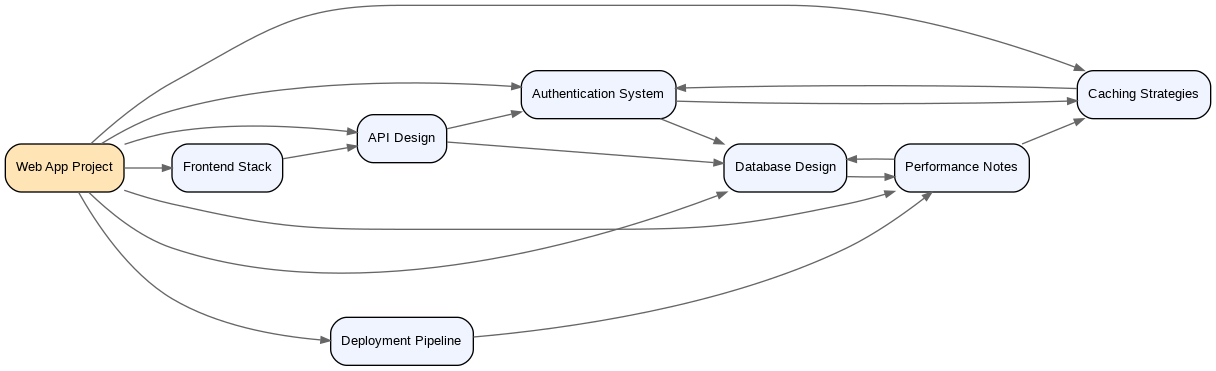


✅  Section 3 complete — all graph operations demonstrated.

────────────────────────────────────────────────────────────────────────
  4 · AI-Powered Document Transforms
────────────────────────────────────────────────────────────────────────

🔄 Transform: SUMMARIZE — Authentication System

- The app implements **JWT-based authentication** with short-lived access tokens (15 minutes) and refresh tokens (7 days), stored in HTTP-only cookies.
- Security measures include hashing passwords with bcrypt (cost factor 12), rate limiting login attempts to 5 per minute, and rotating refresh tokens on each use.


🔗 Transform: GENERATE_LINKS — Authentication System

- [[JWT-based authentication]]
- [[refresh tokens]]
- [[Database Design]]
- [[bcrypt]]
- [[Rate limiting]]
- [[caching-strategies]]
- [[HTTP-only cookies]]
- [[access tokens]]
- [[session management]]
- [[security best practices]]


✅ Transform: EXTRACT_TODOS — Performance Notes

## Todo List

- [ ] Use `EXPLAIN ANALYZE` before deployi

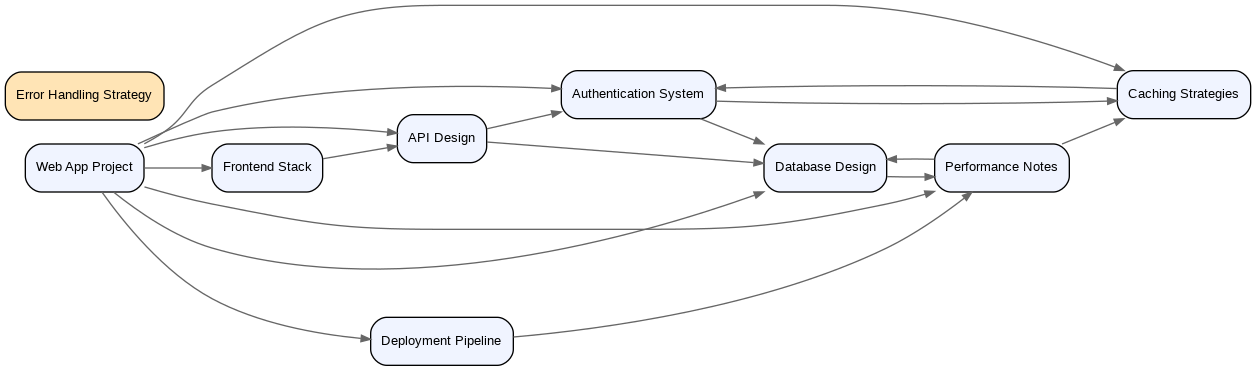


✅  Section 6 complete — AI-powered maintenance demonstrated.

────────────────────────────────────────────────────────────────────────
  7 · Multi-Hop Reasoning Across the Knowledge Graph
────────────────────────────────────────────────────────────────────────

🧠 Complex multi-hop question:
   If we increase our traffic from 1000 RPS to 5000 RPS sustained, what changes would be needed across the entire stack — from database connection pooling, to caching, to authentication token handling, to deployment infrastructure?

   🔧 Agent calls: iwe_find({'query': 'traffic increase 1000 RPS to 5000 RPS database connection pooling caching authentication token deployment infrastructure'})
   🔧 Agent calls: iwe_find({'query': 'scaling applications to handle increased traffic load'})
   🔧 Agent calls: iwe_find({'query': 'performance optimization increasing traffic RPS'})
   🔧 Agent calls: iwe_find({'query': 'increasing RPS recommendations infrastructure adjustments'})
   🔧 Agent calls: iwe_find({'

In [2]:
print("─" * 72)
print("  6 · AI-Powered Knowledge Graph Maintenance")
print("─" * 72)


def analyze_knowledge_gaps(model: str = "gpt-4o-mini") -> str:
    stats_info = json.dumps(kg.stats(), indent=2)
    titles = [f"- {d.title} ({k}): links to {d.outgoing_links}"
              for k, d in kg.documents.items()]
    graph_overview = "\n".join(titles)

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": (
                "You are a knowledge management consultant. Analyze this "
                "knowledge graph and identify: (1) missing topics that should "
                "exist, (2) documents that should be linked but aren't, "
                "(3) areas that need more detail. Be specific and actionable."
            )},
            {"role": "user", "content": (
                f"Knowledge base stats:\n{stats_info}\n\n"
                f"Document structure:\n{graph_overview}"
            )},
        ],
        temperature=0.4, max_tokens=1000,
    )
    return response.choices[0].message.content.strip()


def generate_new_note(topic: str, related_keys: list[str],
                      model: str = "gpt-4o-mini") -> str:
    context_parts = []
    for key in related_keys[:3]:
        doc = kg.get(key)
        if doc:
            context_parts.append(f"## {doc.title}\n{doc.raw_content[:400]}")
    context = "\n\n".join(context_parts)

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": (
                "You are a technical writer. Generate a new markdown note "
                "about the given topic. Use wiki-links [[like-this]] to "
                "reference related existing documents. Include relevant "
                "headers, code examples where appropriate, and hashtag tags."
            )},
            {"role": "user", "content": (
                f"Topic: {topic}\n\n"
                f"Related existing notes for context:\n{context}\n\n"
                f"Available documents to link to: {list(kg.documents.keys())}"
            )},
        ],
        temperature=0.5, max_tokens=1200,
    )
    return response.choices[0].message.content.strip()


print("\n🔍 Analyzing knowledge gaps...\n")
gaps = analyze_knowledge_gaps()
print(gaps)

print("\n\n📝 Generating a new note: 'Error Handling Strategy'...\n")
new_note = generate_new_note(
    "Error Handling Strategy",
    related_keys=["api-design", "authentication", "frontend-stack"],
)
print(new_note[:1000] + "\n... (truncated)")

kg.add_document("error-handling", new_note)
print(f"\n✅  Added 'error-handling' to knowledge graph. "
      f"Total documents: {len(kg.documents)}")

dot_output = kg.export_dot(highlight_key="error-handling")
try:
    import graphviz
    src = graphviz.Source(dot_output)
    src.render("knowledge_graph_v2", format="png", cleanup=True)
    print("✅  Updated graph rendered to 'knowledge_graph_v2.png'")
    try:
        from IPython.display import Image, display
        display(Image("knowledge_graph_v2.png"))
    except ImportError:
        pass
except Exception as e:
    print(f"   ⚠ Graphviz rendering skipped: {e}")

print("\n✅  Section 6 complete — AI-powered maintenance demonstrated.\n")

print("─" * 72)
print("  7 · Multi-Hop Reasoning Across the Knowledge Graph")
print("─" * 72)

complex_question = (
    "If we increase our traffic from 1000 RPS to 5000 RPS sustained, "
    "what changes would be needed across the entire stack — from database "
    "connection pooling, to caching, to authentication token handling, "
    "to deployment infrastructure?"
)

print(f"\n🧠 Complex multi-hop question:\n   {complex_question}\n")
answer = run_agent(complex_question, max_turns=8)
print(f"\n💡 Agent Answer:\n{answer}")

print("\n\n" + "=" * 72)
print("  ✅  TUTORIAL COMPLETE")
print("=" * 72)
print("""
You've explored all the core concepts of IWE:

  1. Knowledge Graph    — Documents as nodes, links as edges
  2. Markdown Parsing   — Wiki-links, headers, tags
  3. Maps of Content    — Hierarchical organisation (MOC)
  4. Graph Operations   — find, retrieve, tree, squash, stats, export
  5. AI Transforms      — Rewrite, summarize, expand, extract todos
  6. Agentic Retrieval  — AI agent navigating your knowledge graph
  7. Graph Maintenance  — AI-powered gap analysis and note generation
  8. Multi-Hop Reasoning — Cross-document synthesis

To use IWE for real (with your editor):
  → https://github.com/iwe-org/iwe
  → https://iwe.md/quick-start

IWE supports VS Code, Neovim, Zed, and Helix via LSP.
""")